# 🚧 Road Damage Detection

## End-to-End Computer Vision & Object Detection Project

This project develops an end-to-end computer vision system for detecting road damage from real-world road images.

Unlike image classification, where the model predicts a label for an entire image, object detection must identify:

- What type of damage is present
- Where the damage is located
- The bounding box surrounding each damage instance
- The confidence associated with each detection

The project uses the RDD2022 dataset and follows a complete computer vision workflow:
```
Raw Data
→ Dataset Audit
→ Annotation Analysis
→ Data Quality Validation
→ Dataset Splitting
→ YOLO Format Conversion
→ Object Detection Training
→ Evaluation
→ Error Analysis
→ Inference
→ Production Deployment
```
The objective is not only to train a detection model, but to build a reproducible and production-oriented object detection pipeline.

## 1.1 Problem Definition

Road damage can reduce road safety, increase maintenance requirements, and create additional operational costs.

The goal of this project is to build a computer vision system that automatically detects road damage from images.

For each detected damage instance, the system should provide:

1. The damage category
2. The spatial location
3. A bounding box
4. A confidence score

The prediction can therefore be represented as:
```
Image
↓
Object Detector
↓
Detection 1 → Class + Bounding Box + Confidence
Detection 2 → Class + Bounding Box + Confidence
Detection N → Class + Bounding Box + Confidence
```
This makes the problem a **multi-class object detection task**.

## 1.2 Why Object Detection?

A road image may contain multiple damage instances at different locations and scales.

For example, a single image may contain:

- A longitudinal crack
- A transverse crack
- A pothole

A classification model would provide only an image-level prediction and would not identify where each damage instance is located.

Object detection preserves both:

**Semantic Information**
→ What is the damage?

**Spatial Information**
→ Where is the damage?

Therefore, object detection is more suitable for road-damage inspection than image classification.

## 1.3 Dataset Overview

The project uses the **RDD2022 Road Damage Dataset**.

The raw dataset is organized into multiple geographical or acquisition sources:

- China Drone
- China MotorBike
- Czech
- India
- Japan
- Norway
- United States

The raw data contains road images together with annotation files.

The annotation files are provided in XML format and contain image metadata, object labels, and bounding-box coordinates.

Before any transformation is applied, the raw dataset is inspected programmatically to understand its actual structure and annotation taxonomy.

## 1.4 Annotation Verification Principle

Object detection depends directly on the quality and correctness of ground-truth annotations.

For this reason, the annotation format and class mapping should not be assumed in advance.

Instead, the raw annotation files are inspected first to determine:

- The annotation hierarchy
- Image identifiers
- Class names
- Bounding-box coordinates
- Image dimensions
- Additional annotation attributes

This verification step reduces the risk of introducing incorrect labels during dataset conversion.

# 2. Dataset Audit

Before training any object detection model, we first need to understand the raw dataset.

The dataset audit is designed to answer the following questions:

- How many images are available?
- How many annotation files exist?
- Which data sources are represented?
- Which annotation labels actually occur?
- How many objects belong to each label?
- Are images and annotations correctly associated?
- Are the bounding boxes valid?
- Are there corrupted or duplicated samples?
- Are there unexpected labels that require normalization?

The raw RDD2022 dataset is kept unchanged throughout this process.

All transformations will be written to separate processed directories.

## 2.1 Import Libraries

The following libraries are used for dataset inspection, XML parsing, tabular analysis, visualization, and image validation.

The goal at this stage is not model training.

We are building the data-analysis foundation required for a reliable object detection pipeline.

In [ ]:
# Import libraries for dataset inspection, XML parsing, analysis, and image validation
from pathlib import Path
from collections import Counter
import xml.etree.ElementTree as ET

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

## 2.2 Project Paths

The project follows a strict separation between raw data and generated data.

The original RDD2022 dataset is stored under:

`data/RDD2022`

This directory will remain untouched.

Processed datasets, dataset splits, and YOLO-formatted labels will be stored separately.

This structure improves:

- Reproducibility
- Traceability
- Data integrity
- Experiment management

In [ ]:
# Set project and dataset paths
PROJECT_ROOT = Path.cwd()

DATA_ROOT = PROJECT_ROOT / "C:\\Users\\mahmu\\OneDrive\\Desktop\\Road Damage Detection\\data"
RAW_DATASET = DATA_ROOT / "RDD2022"

print(f"Project root : {PROJECT_ROOT}")
print(f"Dataset root : {RAW_DATASET}")
print(f"Exists       : {RAW_DATASET.exists()}")

Project root : c:\Users\mahmu\OneDrive\Desktop\Road Damage Detection\📓 notebook
Dataset root : C:\Users\mahmu\OneDrive\Desktop\Road Damage Detection\data\RDD2022
Exists       : True


### Interpretation

The dataset path was resolved successfully.

The raw RDD2022 directory exists and is accessible from the notebook, confirming that the notebook can work directly with the original dataset.

## 2.3 Inspect the Raw Dataset Structure

The first step is to inspect the top-level structure of the RDD2022 dataset.

This allows us to identify the available data sources before analyzing individual images and annotations.

At this stage, we intentionally inspect the directory structure instead of hard-coding source names.

In [ ]:
# Check that the dataset exists and list the top-level dataset contents
if not RAW_DATASET.exists():
    raise FileNotFoundError(
        f"RDD2022 dataset not found at: {RAW_DATASET}"
    )

for path in sorted(RAW_DATASET.iterdir()):
    if path.is_dir():
        print(f"[DIR]  {path.name}")
    else:
        print(f"[FILE] {path.name}")

[DIR]  China_Drone
[DIR]  China_MotorBike
[DIR]  Czech
[DIR]  India
[DIR]  Japan
[DIR]  Norway
[DIR]  United_States


### Interpretation

The raw dataset contains seven identified sources:

- China_Drone
- China_MotorBike
- Czech
- India
- Japan
- Norway
- United_States

The source-level organization will be preserved during the audit because different acquisition environments may introduce differences in image appearance, camera viewpoint, road conditions, and annotation behavior.

## 2.4 Dataset Sources

The dataset contains multiple geographical or acquisition sources.

Source diversity is important in computer vision because models may encounter variations in:

- Road appearance
- Camera viewpoint
- Lighting
- Image quality
- Traffic environment
- Damage characteristics

We therefore record the available sources explicitly before continuing with annotation analysis.

In [ ]:
# Discover dataset sources directly from the raw directory structure
sources = sorted(
    path.name
    for path in RAW_DATASET.iterdir()
    if path.is_dir()
)

print(f"Number of sources: {len(sources)}")
print()

for source in sources:
    print(f"- {source}")

Number of sources: 7

- China_Drone
- China_MotorBike
- Czech
- India
- Japan
- Norway
- United_States


### Interpretation

The audit identified **7 data sources**:

China_Drone, China_MotorBike, Czech, India, Japan, Norway, and United_States.

This confirms that the dataset is geographically and operationally diverse, which may introduce distribution differences that should be considered during later model evaluation.

## 2.5 Image and Annotation Inventory

Before analyzing individual annotations, we quantify the number of image and XML files available in each source.

This provides an initial inventory of the raw dataset and helps identify source-level differences between images and annotations.

A mismatch between image count and annotation count does not automatically indicate a data-quality problem.

For example, a dataset may contain test images without corresponding ground-truth annotations.

Therefore, aggregate counts will be followed by image-to-annotation consistency checks.

In [ ]:
# Count image files and XML annotation files for each dataset source
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

source_stats = []

for source in sources:
    source_path = RAW_DATASET / source

    image_files = [
        p for p in source_path.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    xml_files = [
        p for p in source_path.rglob("*.xml")
        if p.is_file()
    ]

    source_stats.append({
        "Source": source,
        "Images": len(image_files),
        "XML Annotations": len(xml_files)
    })

source_stats_df = pd.DataFrame(source_stats)

source_stats_df

,Source,Images,XML Annotations
0,China_Drone,2401,2401
1,China_MotorBike,2477,1977
2,Czech,3538,2829
3,India,9665,7706
4,Japan,13133,10506
5,Norway,10201,8161
6,United_States,6005,4805


### Interpretation

The current inventory contains **47,420 image files** and **38,385 XML annotation files** across the seven sources.

The source-level distribution is:

- China_Drone: 2,401 images / 2,401 XML files
- China_MotorBike: 2,477 images / 1,977 XML files
- Czech: 3,538 images / 2,829 XML files
- India: 9,665 images / 7,706 XML files
- Japan: 13,133 images / 10,506 XML files
- Norway: 10,201 images / 8,161 XML files
- United_States: 6,005 images / 4,805 XML files

The difference between image and annotation counts requires further investigation rather than being treated automatically as an error.

This is particularly important because some source directories contain test images that may not have ground-truth XML annotations.

## 2.6 Inspecting the Raw XML Annotation Format

The raw annotation files are stored as XML.

Before implementing a general annotation parser, we inspect an actual annotation file from the dataset.

The objective is to identify the exact structure used by the source data, including:

- Image filename
- Image dimensions
- Object labels
- Bounding-box coordinates
- Additional annotation attributes

This prevents assumptions about the annotation format from propagating into the preprocessing pipeline.

In [ ]:
# Inspect a real XML annotation file before implementing the parser
xml_files = sorted(
    RAW_DATASET.rglob("*.xml")
)

if not xml_files:
    raise FileNotFoundError(
        "No XML annotation files were found."
    )

sample_xml = xml_files[0]

print(f"Sample annotation:\n{sample_xml}")
print()

print(sample_xml.read_text(
    encoding="utf-8",
    errors="ignore"
)[:5000])

Sample annotation:
C:\Users\mahmu\OneDrive\Desktop\Road Damage Detection\data\RDD2022\China_Drone\train\annotations\xmls\China_Drone_000000.xml

<annotation>
	<folder>images</folder>
	<filename>China_Drone_000000.jpg</filename>
	<size>
		<width>512</width>
		<height>512</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>D10</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>323</xmin>
			<ymin>213</ymin>
			<xmax>390</xmax>
			<ymax>245</ymax>
		</bndbox>
	</object>
</annotation>


### Interpretation

The inspected XML follows an object-annotation structure containing:

- An image filename
- Image width, height, and depth
- Object entries
- Object class names
- Bounding-box coordinates

The sample image has dimensions of **512 × 512 × 3**, and the annotation contains a damage object with bounding-box coordinates:

`xmin = 323, ymin = 213, xmax = 390, ymax = 245`

The XML inspection confirms that the dataset provides the information required to construct object-detection labels.

## 2.7 Parse the XML Structure

After visually inspecting the raw XML, we parse the file programmatically.

The purpose of this step is to confirm the XML hierarchy and identify the available top-level elements before building the complete annotation extraction logic.

In [ ]:
# Parse the sample XML file and inspect its root and direct child elements
tree = ET.parse(sample_xml)
root = tree.getroot()

print("Root tag:", root.tag)
print("\nChildren:")

for child in root:
    print("-", child.tag)

Root tag: annotation

Children:
- folder
- filename
- size
- segmented
- object


### Interpretation

The XML root element is:

`annotation`

Its direct children include:

- `folder`
- `filename`
- `size`
- `segmented`
- `object`

This confirms that the dataset follows a Pascal VOC-style object annotation structure, where each `object` element represents an annotated damage instance.

## 2.8 Discovering the Raw Annotation Labels

The class taxonomy is one of the most important components of an object detection dataset.

Although the project will eventually use a normalized YOLO class mapping, we first inspect the labels exactly as they appear in the raw XML files.

This prevents us from incorrectly assuming that the raw dataset contains only the final four project classes.

The discovered labels will later be analyzed and mapped into the final detection taxonomy only after their meaning and consistency have been verified.

In [ ]:
# Extract all object labels from the raw XML annotations
class_counter = Counter()

for xml_file in xml_files:
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()

        for obj in root.findall(".//object"):
            name = obj.find("name")

            if name is not None and name.text:
                class_counter[name.text.strip()] += 1

    except ET.ParseError:
        continue

class_counter

Counter({'D00': 26016,
         'D10': 11830,
         'D20': 10617,
         'D40': 6544,
         'D44': 5057,
         'D50': 3581,
         'Repair': 1046,
         'D43': 793,
         'D01': 179,
         'D11': 45,
         'Block crack': 3,
         'D0w0': 1})

### Interpretation

The raw annotations currently contain **12 distinct label names**:

| Raw Label | Object Count |
|---|---:|
| D00 | 26,016 |
| D10 | 11,830 |
| D20 | 10,617 |
| D40 | 6,544 |
| D44 | 5,057 |
| D50 | 3,581 |
| Repair | 1,046 |
| D43 | 793 |
| D01 | 179 |
| D11 | 45 |
| Block crack | 3 |
| D0w0 | 1 |

A total of **65,712 annotated objects** were found across the parsed XML files.

This result is important because the raw annotation taxonomy is broader than the four high-level damage categories initially expected for the project.

Therefore, no label conversion should be performed yet.

The next step is to investigate these raw labels and determine which labels correspond to the intended road-damage categories and which labels represent additional or source-specific annotations.

## 2.9 Raw Object Distribution

Object-level class distribution is more informative than simply counting images because one image may contain multiple damage instances.

For example:

One Image
→ Multiple Objects
→ Multiple Annotations

Therefore, the distribution below represents the number of annotated objects rather than the number of images.

In [ ]:
# Create a sorted table showing the number of annotated objects per raw label
class_distribution = (
    pd.DataFrame(
        class_counter.items(),
        columns=["Class", "Object Count"]
    )
    .sort_values(
        "Object Count",
        ascending=False
    )
    .reset_index(drop=True)
)

class_distribution

,Class,Object Count
0,D00,26016
1,D10,11830
2,D20,10617
3,D40,6544
4,D44,5057
5,D50,3581
6,Repair,1046
7,D43,793
8,D01,179
9,D11,45


### Interpretation

The object distribution is highly uneven.

`D00` is the dominant raw annotation label with **26,016 objects**, while several labels occur very rarely.

For example:

- D11 appears 45 times
- Block crack appears 3 times
- D0w0 appears once

This creates an important dataset-preparation question:

> Should all raw labels be retained as independent detection classes, or should some labels be mapped into a smaller standardized taxonomy?

That decision must be based on the actual meaning of each label rather than frequency alone.

This will be resolved before YOLO label generation.

## 2.10 Visualizing the Raw Annotation Distribution

A visualization makes the imbalance between annotation categories easier to interpret.

The chart represents **annotated object instances per raw label**, not image counts.

This distinction is important because object detection datasets may contain multiple objects within the same image.

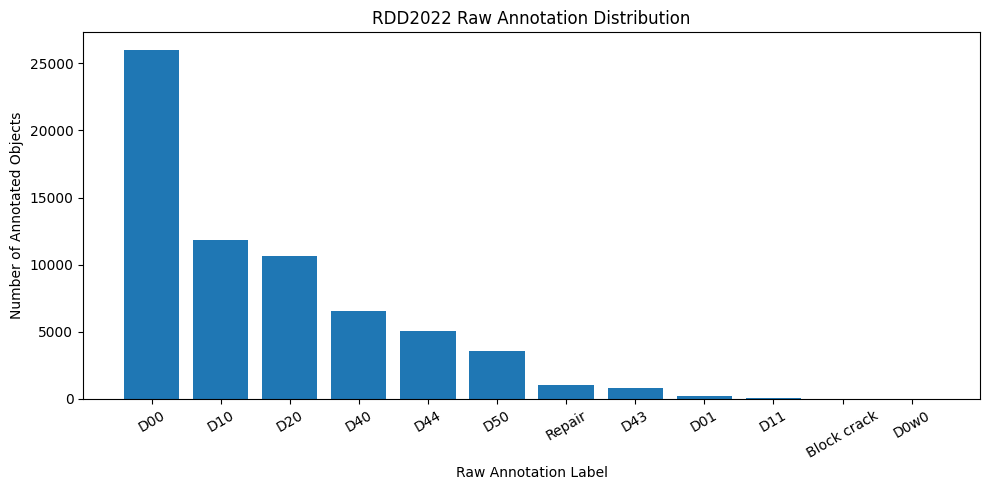

In [13]:
# Visualize the number of annotated objects for each raw label

plt.figure(figsize=(10, 5))

plt.bar(
    class_distribution["Class"],
    class_distribution["Object Count"]
)

plt.title("RDD2022 Raw Annotation Distribution")
plt.xlabel("Raw Annotation Label")
plt.ylabel("Number of Annotated Objects")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Interpretation

The distribution shows a strong concentration of annotations in a small number of labels, particularly `D00`, `D10`, and `D20`.

At the same time, several labels are extremely rare.

This does not yet determine whether the final training dataset should be imbalanced because the raw taxonomy may later be normalized into the project's target classes.

Before any class balancing or model-level decisions are made, the annotation semantics must be verified.

## 💼 Business Thinking

From an operational perspective, road-damage detection is a decision-support system for identifying infrastructure problems from visual data.

The value of such a system depends on reliable detection across different damage categories and operating environments.

A model that performs well only on the most frequent damage pattern may fail to provide consistent inspection coverage.

Therefore, the project will focus on:

- Reliable annotation quality
- Consistent class definitions
- Detection performance across damage categories
- Robustness across different data sources

## Summary

In this stage, we established the initial data foundation for the Road Damage Detection project.

We:

- Defined the object detection problem
- Explained why localization is required
- Preserved the raw RDD2022 dataset
- Identified 7 dataset sources
- Counted images and XML annotation files
- Inspected a real XML annotation
- Verified the annotation hierarchy
- Extracted the raw object labels
- Calculated object-level class frequencies
- Visualized the raw annotation distribution

The most important discovery at this stage is that the raw XML files contain **12 distinct annotation labels**, not only the four high-level damage categories initially expected.

Therefore, the next stage will focus on **annotation semantics and data-quality validation** before any class mapping or YOLO conversion is performed.

The immediate goal is:

Raw XML
```
→ Validate Image / Annotation Relationships
→ Validate Bounding Boxes
→ Investigate Raw Labels
→ Determine Final Class Mapping
→ Visualize Ground Truth
```